<>:61: SyntaxWarning: invalid escape sequence '\g'
<>:61: SyntaxWarning: invalid escape sequence '\g'
C:\Users\MSI\AppData\Local\Temp\ipykernel_48344\2942070016.py:61: SyntaxWarning: invalid escape sequence '\g'
  plt.title(f'Corrected L-Plane ($\gamma={gamma}$)')


 Image loaded. Applying Gamma = 0.5 to the L-plane...


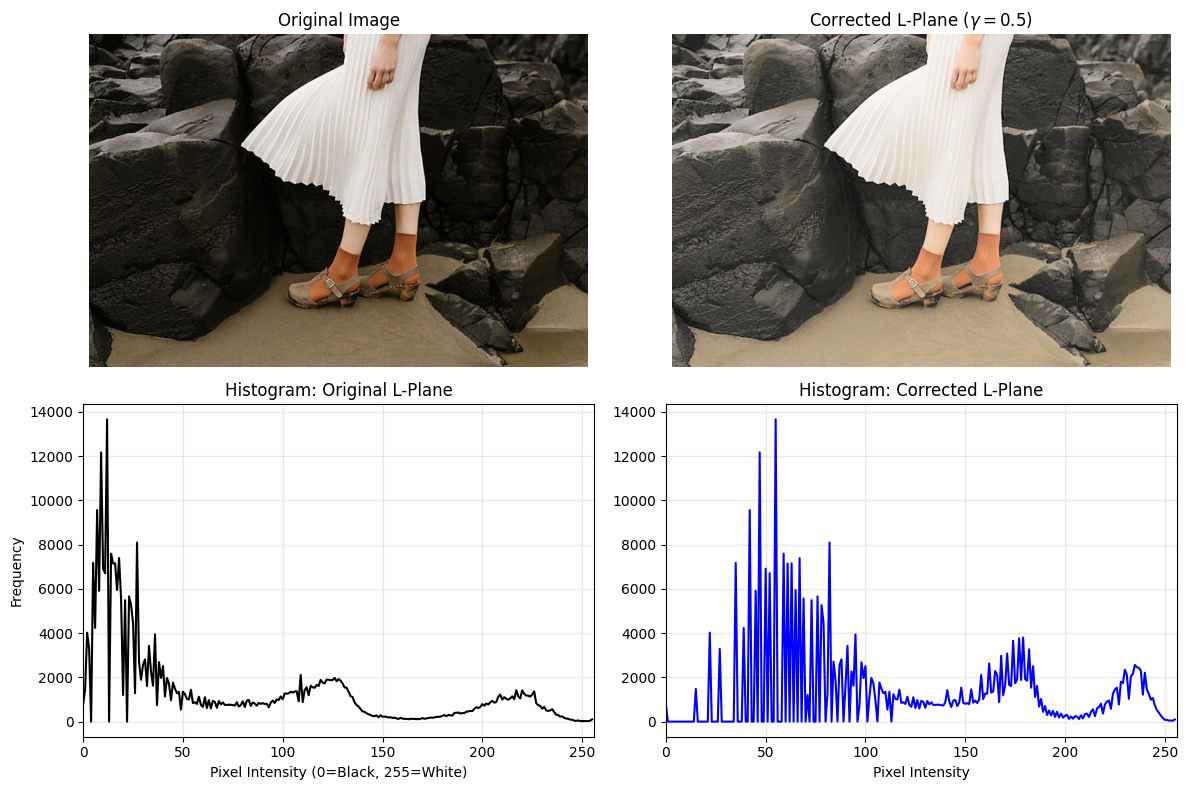

✅ Saved result to: d:\computer_Vision_Inclass_11_26\result_highlights.jpg


In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# 1. We use your specific image filename
filename = 'highlights_and_shadows.jpg'
# 2. We set the path (assuming it is in your D: folder)
file_path = fr"d:\computer_Vision_Inclass_11_26\{filename}"

# 3. Gamma Selection
# We use 0.5 to lift the shadows in the dark rocks
gamma = 0.5

# --- LOAD IMAGE ---
img = cv.imread(file_path, cv.IMREAD_COLOR)

if img is None:
    print(" ERROR: Image not found.")
    print(f"Please ensure '{filename}' is inside 'd:\\computer_Vision_Inclass_11_26'")
else:
    print(f" Image loaded. Applying Gamma = {gamma} to the L-plane...")

    # 1. Convert BGR to Lab Color Space
    # L = Lightness (Intensity), a = Green-Red, b = Blue-Yellow
    lab_image = cv.cvtColor(img, cv.COLOR_BGR2Lab)

    # 2. Split into Channels
    l_channel, a_channel, b_channel = cv.split(lab_image)

    # 3. Apply Gamma Correction to L-Channel ONLY
    # Formula: ((pixel / 255) ^ gamma) * 255
    table = np.array([((i / 255.0) ** gamma) * 255 
                      for i in np.arange(0, 256)]).astype("uint8")
    
    # We only change the Lightness, keeping colors (a, b) exactly the same
    l_corrected = cv.LUT(l_channel, table)

    # 4. Merge channels back together and convert to BGR
    lab_corrected = cv.merge((l_corrected, a_channel, b_channel))
    result_img = cv.cvtColor(lab_corrected, cv.COLOR_Lab2BGR)

    # --- CALCULATE HISTOGRAMS ---
    # Histogram of Original L-Plane
    hist_original = cv.calcHist([l_channel], [0], None, [256], [0, 256])
    # Histogram of Corrected L-Plane
    hist_corrected = cv.calcHist([l_corrected], [0], None, [256], [0, 256])

    # --- DISPLAY RESULTS ---
    plt.figure(figsize=(12, 8))

    # 1. Original Image (Convert BGR to RGB for Matplotlib)
    plt.subplot(2, 2, 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    # 2. Corrected Image
    plt.subplot(2, 2, 2)
    plt.imshow(cv.cvtColor(result_img, cv.COLOR_BGR2RGB))
    plt.title(f'Corrected L-Plane ($\gamma={gamma}$)')
    plt.axis('off')

    # 3. Histograms
    plt.subplot(2, 2, 3)
    plt.plot(hist_original, color='black', label='Original L')
    plt.title('Histogram: Original L-Plane')
    plt.xlabel('Pixel Intensity (0=Black, 255=White)')
    plt.ylabel('Frequency')
    plt.xlim([0, 256])
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.plot(hist_corrected, color='blue', label='Corrected L')
    plt.title(f'Histogram: Corrected L-Plane')
    plt.xlabel('Pixel Intensity')
    plt.xlim([0, 256])
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Save the result
    save_path = fr"d:\computer_Vision_Inclass_11_26\result_highlights.jpg"
    cv.imwrite(save_path, result_img)
    print(f"✅ Saved result to: {save_path}")